<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/DSPEC_SEC_CHU_wavespectra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "wavespectra[extra]"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.3/164.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 12.1 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=a6ae3934a9fa85be5c073bd0dbbee76521cb6d3e88fe5253950c982ab4e1bef0
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
  Attempting uninstall: tomlkit
    Found existing installation: tomlkit 0.14.0
    Uninstalling tomlkit-0.14.0:
      Successfully uninstalled tomlkit-0.14.0
ERROR: pip's dependency resolver does

In [2]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import wavespectra
from google.colab import drive

In [3]:
# ============================================================
# 1. Montar Google Drive
# ============================================================

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# 2. Caminho dos arquivos DSpec
# ============================================================

caminho_diretorio = '/content/drive/MyDrive/Ondas/Dados/marco2025/SCO1/DSpec_2/'

arquivos = sorted(glob.glob(os.path.join(caminho_diretorio, "*.txt")))

In [5]:
# ============================================================
# 3. Ler todos os espectros e armazenar
# ============================================================

lista_espectros = []

for arquivo in arquivos:

    nome = os.path.basename(arquivo)

    # Ler matriz 64 x 90
    energia = np.loadtxt(arquivo, comments='%')
    energia = energia / 1e6

    lista_espectros.append(energia)

In [6]:
# ============================================================
# 4. Transformar em matriz 3D
# ============================================================

# Dimensão:
# tempo x frequência x direção

espectros = np.array(lista_espectros)

print("Dimensão dos dados:")
print(espectros.shape)

Dimensão dos dados:
(442, 64, 90)


In [7]:
# ============================================================
# 5. Calcular espectro direcional médio do período
# ============================================================
espectro_medio = np.mean(espectros, axis=0)

In [8]:
# ============================================================
# 6. Criar coordenadas
# ============================================================

f0 = 0.00878906
df = 0.015625
frequencias = f0 + np.arange(64)*df

direcoes = np.linspace(0,360,90,endpoint=False)

# Criar DataArray

da = xr.DataArray(
    data=espectro_medio,
    dims=["freq","dir"],
    coords={
        "freq": frequencias,
        "dir": direcoes
    },
    name="efth"
)

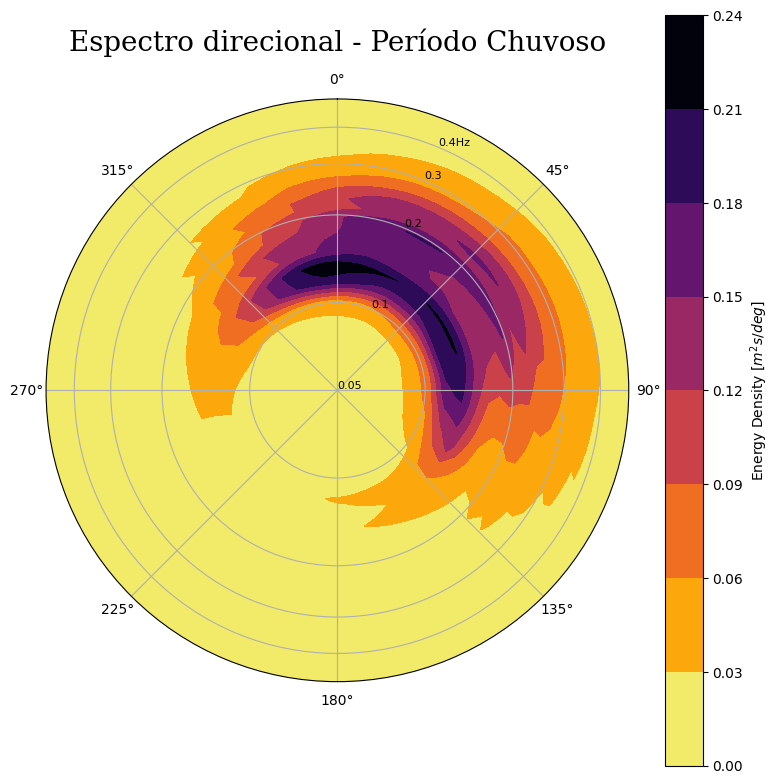

In [9]:
# ============================================================
# 7. Plotar espectro médio
# ============================================================

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw={"projection":"polar"}
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

plt.sca(ax)

da.spec.plot(
    rmin=0.05,
    rmax=0.5,
    kind="contourf",
    as_period=False,
    normalised=False,
    cmap="inferno_r",
    add_colorbar=True
)

plt.title(
    "Espectro direcional - Período Chuvoso",
    font="serif",
    fontsize=20,
    pad=35
)

plt.tight_layout()

saida = os.path.join(
    caminho_diretorio,
    "Resultado_2D_DSPEC.png"
)

plt.savefig(
    saida,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# ============================================================
# 8. Ler e calcular espectro médio para período menos chuvoso
# ============================================================

caminho_diretorio2 = '/content/drive/MyDrive/Ondas/Dados/novembro2025/SCO2/DSpec_2/'
arquivos2 = sorted(glob.glob(os.path.join(caminho_diretorio2, "*.txt")))

In [11]:
lista_espectros2 = []
for arquivo in arquivos2:
    energia = np.loadtxt(arquivo, comments='%')
    energia = energia / 1e6
    lista_espectros2.append(energia)

espectros2 = np.array(lista_espectros2)
espectro_medio2 = np.mean(espectros2, axis=0)

In [12]:
# ============================================================
# 9. Criar DataArrays para os dois períodos
# ============================================================

da_chuvoso = xr.DataArray(
    data=espectro_medio,
    dims=["freq","dir"],
    coords={"freq": frequencias, "dir": direcoes},
    name="efth"
)

da_menos_chuvoso = xr.DataArray(
    data=espectro_medio2,
    dims=["freq","dir"],
    coords={"freq": frequencias, "dir": direcoes},
    name="efth"
)

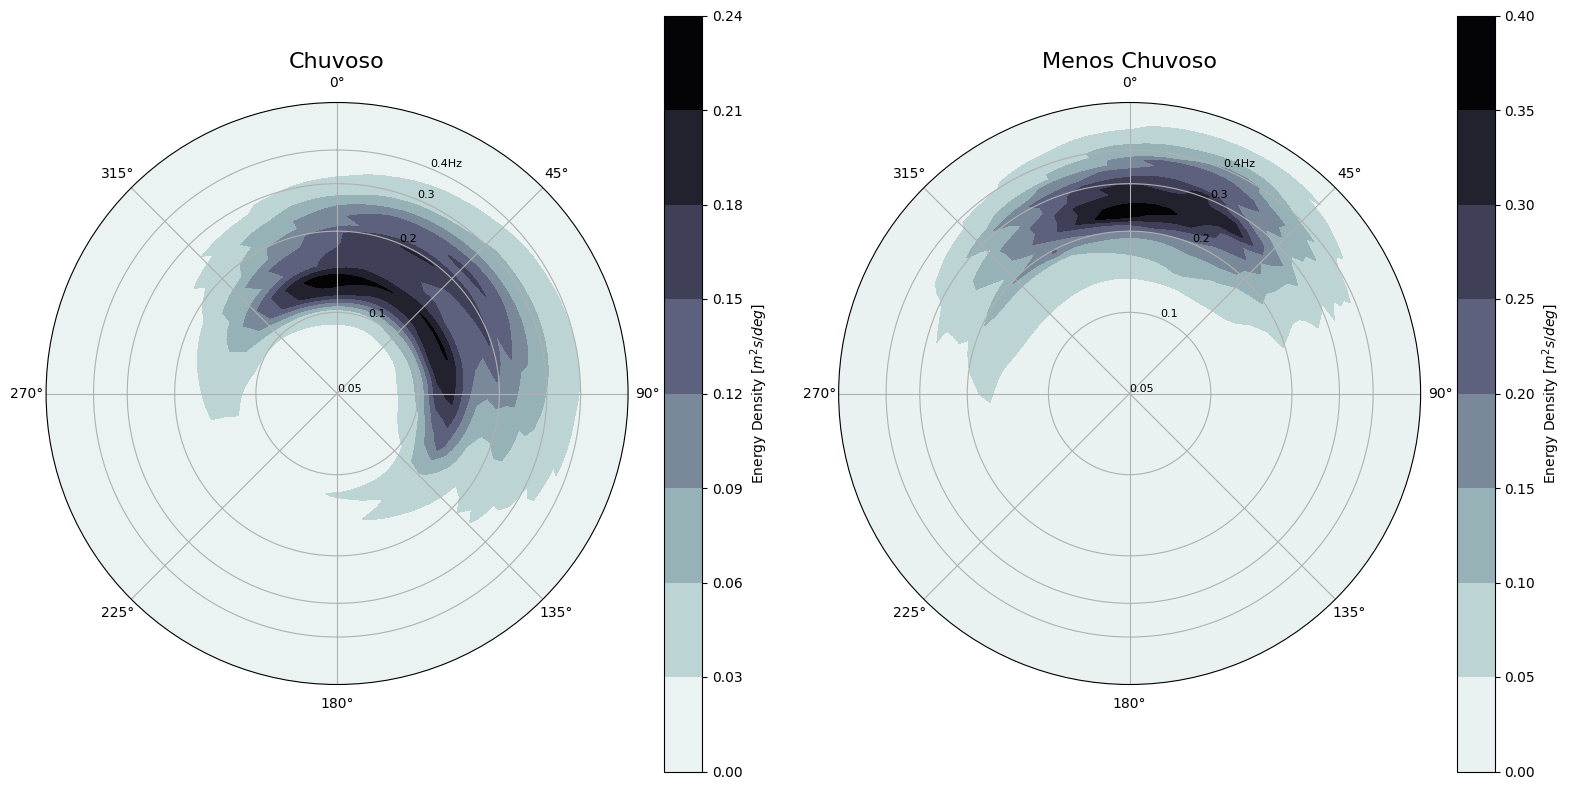

In [21]:
# ============================================================
# 10. Plotar lado a lado
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16,8),
    subplot_kw={"projection":"polar"}
)

# Configurações comuns
for ax in axes:
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

# Plot período chuvoso
plt.sca(axes[0])
da_chuvoso.spec.plot(
    rmin=0.05, rmax=0.6,
    kind="contourf",
    as_period=False,
    normalised=False,
    cmap="bone_r",
    add_colorbar=True
)
axes[0].set_title("Chuvoso", fontsize=16, pad=25)

# Plot período menos chuvoso
plt.sca(axes[1])
da_menos_chuvoso.spec.plot(
    rmin=0.05, rmax=0.6,
    kind="contourf",
    as_period=False,
    normalised=False,
    cmap="bone_r",
    add_colorbar=True
)
axes[1].set_title("Menos Chuvoso", fontsize=16, pad=25)

plt.tight_layout()

saida_comparacao = os.path.join(
    caminho_diretorio,
    "Comparacao_2D_DSPEC.png"
)

plt.savefig(saida_comparacao, dpi=300, bbox_inches="tight")
plt.show()

In [70]:
# ============================================================
# 11. Criar Dataset com os dois períodos
# ============================================================

dset = xr.Dataset(
    {
        "efth": (["Periodo","freq","dir"],
                 np.stack([espectro_medio, espectro_medio2]))
    },
    coords={
        "Periodo": ["Chuvoso", "Menos Chuvoso"],
        "freq": frequencias,
        "dir": direcoes
    }
)

/usr/local/lib/python3.12/dist-packages/xarray/plot/dataarray_plot.py:2145: UserWarning: The following kwargs were not used by contour: 'title_pad'
  primitive = ax.contourf(x, y, z, **kwargs)
/tmp/ipykernel_666/4057366422.py:30: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat:


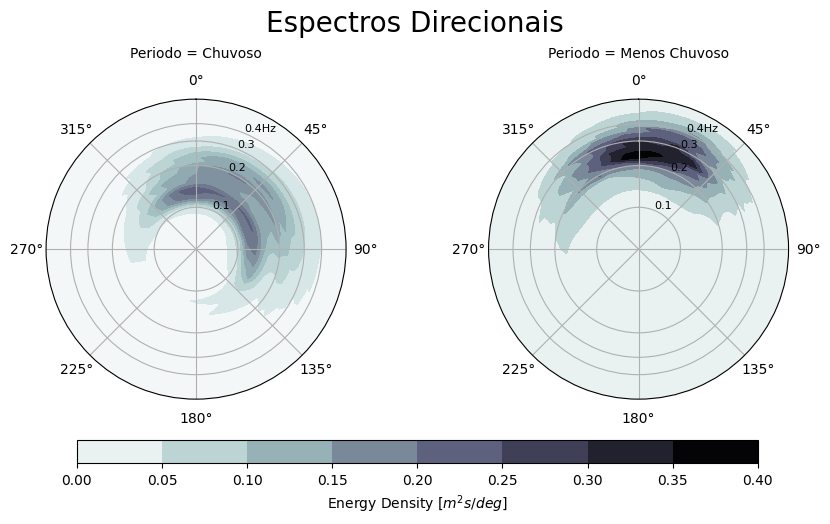

In [86]:
# ============================================================
# 12. Plotar com facetamento (ajuste fino de títulos e layout)
# ============================================================

g = dset.spec.plot(
    col="Periodo",
    figsize=(9,5),
    add_colorbar=True,
    normalised=False,
    show_theta_labels=True,
    show_radii_labels=True,
    radii_ticks=[0.1, 0.2, 0.3, 0.4],
    rmin=0.05,
    rmax=0.6,
    cmap="bone_r",
    cbar_kwargs={
        "orientation": "horizontal",
        "pad": 0.09,
        "aspect": 30,
        "fraction": 0.05
    },
    title_pad=25  # distância entre o título e o gráfico
)

# Ajusta o título geral e espaçamento
plt.suptitle("Espectros Direcionais", fontsize=20, y=0.97)
plt.subplots_adjust(top=0.79, bottom=0.19)

# Se quiser ainda mais controle, pode ajustar manualmente:
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), pad=30, fontsize=10)

saida_facet = os.path.join(
    caminho_diretorio,
    "DSPEC_CHU_SEC.png"
)

plt.savefig(saida_facet, dpi=300, bbox_inches="tight")
plt.show()
